<a href="https://colab.research.google.com/github/GunaSamhith/ML-labActivity/blob/main/10_6_1_KmeansClustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [ ]:
data = pd.read_csv("Old_Faithful_Geyser.csv")

data.head()


,Eruption_Duration,Waiting_Time
0,2.9,80
1,3.1,82
2,2.8,78
3,4.5,95
4,4.7,96


In [ ]:
X = data.iloc[:,[0,1]].values

print(X[:5])

[[ 2.9 80. ]
 [ 3.1 82. ]
 [ 2.8 78. ]
 [ 4.5 95. ]
 [ 4.7 96. ]]


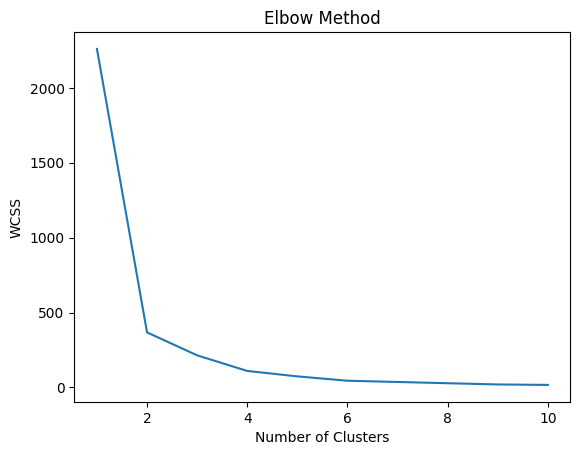

In [ ]:
wcss=[]

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        init="k-means++",
        random_state=42
    )

    kmeans.fit(X)
    wcss.append(kmeans.inertia_)


plt.plot(range(1,11),wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
model = KMeans(
    n_clusters=2,
    init="k-means++",
    random_state=42
)

clusters = model.fit_predict(X)

print(clusters)

[0 0 0 1 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 1 0 0 0 1 1 1 0 0 1 1]


In [ ]:
model = KMeans(
    n_clusters=2,
    init="k-means++",
    random_state=42
)

clusters = model.fit_predict(X)

print(clusters)

[0 0 0 1 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 1 0 0 0 1 1 1 0 0 1 1]


In [ ]:
data["Cluster"] = clusters

data.head()

,Eruption_Duration,Waiting_Time,Cluster
0,2.9,80,0
1,3.1,82,0
2,2.8,78,0
3,4.5,95,1
4,4.7,96,1


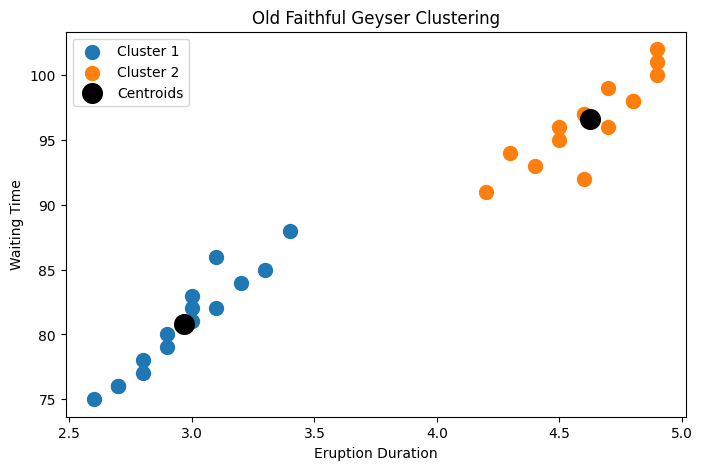

In [ ]:
plt.figure(figsize=(8,5))


plt.scatter(
    X[clusters==0,0],
    X[clusters==0,1],
    s=100,
    label="Cluster 1"
)


plt.scatter(
    X[clusters==1,0],
    X[clusters==1,1],
    s=100,
    label="Cluster 2"
)


plt.scatter(
    model.cluster_centers_[:,0],
    model.cluster_centers_[:,1],
    s=200,
    c="black",
    label="Centroids"
)


plt.title("Old Faithful Geyser Clustering")
plt.xlabel("Eruption Duration")
plt.ylabel("Waiting Time")
plt.legend()
plt.show()